In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Karishma\Downloads\IMDB Dataset.csv\IMDB Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


In [8]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
review       0
sentiment    0
dtype: int64


In [10]:
print("Number of duplicate reviews:")
print(df.duplicated(subset=['review']).sum())

Number of duplicate reviews:
418


In [11]:
df = df.dropna(subset=['review'])

df = df.drop_duplicates(subset=['review'])

print("Dataset after removing missing values and duplicates:")
print(df.shape)

Dataset after removing missing values and duplicates:
(49582, 2)


In [12]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [13]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Karishma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Karishma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Karishma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Karishma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Karishma\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

print("Stopwords and lemmatizer ready!")

Stopwords and lemmatizer ready!


In [15]:
def clean_review(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 4. Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # 5. Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # 6. Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 7. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Tokenization
    words = word_tokenize(text)

    # 9. Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # 10. Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    # 11. Join words back together
    cleaned_text = ' '.join(words)

    return cleaned_text

In [16]:
example = "This movie was AMAZING!!!"

print("Original:")
print(example)

print("\nCleaned:")
print(clean_review(example))

Original:
This movie was AMAZING!!!

Cleaned:
movie amazing


In [17]:
df['cleaned_review'] = df['review'].apply(clean_review)

print("Cleaning completed!")

Cleaning completed!


In [18]:
df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [19]:
for i in range(5):

    print("\n====================================")
    print("REVIEW", i + 1)
    print("====================================")

    print("\nOriginal Review:")
    print(df['review'].iloc[i])

    print("\nCleaned Review:")
    print(df['cleaned_review'].iloc[i])


REVIEW 1

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal o

In [21]:
comparison = df[['review', 'cleaned_review']].head(10)

comparison

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...
5,"Probably my all-time favorite movie, a story o...",probably alltime favorite movie story selfless...
6,I sure would like to see a resurrection of a u...,sure would like see resurrection dated seahunt...
7,"This show was an amazing, fresh & innovative i...",show amazing fresh innovative idea first aired...
8,Encouraged by the positive comments about this...,encouraged positive comment film looking forwa...
9,If you like original gut wrenching laughter yo...,like original gut wrenching laughter like movi...


In [22]:
print("Final number of rows:", len(df))
print("Final number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns)

Final number of rows: 49582
Final number of columns: 3

Columns:
Index(['review', 'sentiment', 'cleaned_review'], dtype='object')


In [23]:
df.to_csv("cleaned_IMDb_reviews.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
X = df['cleaned_review']
y = df['sentiment']

print("Input data shape:", X.shape)
print("Target data shape:", y.shape)

Input data shape: (49582,)
Target data shape: (49582,)


In [26]:
y = y.map({
    'negative': 0,
    'positive': 1
})

print("Sentiment values:")
print(y.value_counts())


Sentiment values:
sentiment
1    24884
0    24698
Name: count, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 39665
Testing data: 9917


In [28]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

print("TF-IDF vectorizer created!")

TF-IDF vectorizer created!


In [29]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (39665, 10000)
Testing TF-IDF shape: (9917, 10000)


In [30]:
model = LogisticRegression(max_iter=1000)

print("Logistic Regression model created!")

Logistic Regression model created!


In [31]:
model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [32]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed!")

Prediction completed!


In [33]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8926086518100232
Accuracy Percentage: 89.26086518100233 %


In [34]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive']
    )
)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4940
    Positive       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [35]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4352  588]
 [ 477 4500]]


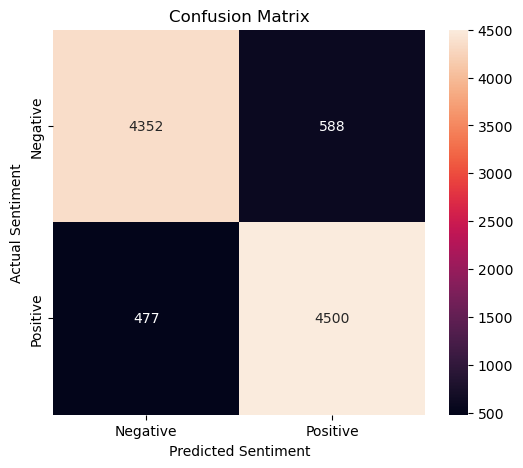

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")

plt.show()

In [37]:
def predict_sentiment(review):

    # Clean the review
    cleaned = clean_review(review)

    # Convert to TF-IDF
    vectorized = tfidf.transform([cleaned])

    # Predict sentiment
    prediction = model.predict(vectorized)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [38]:
review = "This movie was absolutely amazing. I loved every minute of it!"

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: This movie was absolutely amazing. I loved every minute of it!
Predicted Sentiment: Positive


In [39]:
review = "This movie was terrible and boring. I completely hated it."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: This movie was terrible and boring. I completely hated it.
Predicted Sentiment: Negative


In [40]:
reviews = [
    "I absolutely loved this movie. It was fantastic!",
    "The movie was boring and a complete waste of time.",
    "Amazing acting and a wonderful story.",
    "I hated this movie. It was terrible.",
    "One of the best movies I have ever watched."
]

for review in reviews:

    print("\nReview:", review)
    print("Sentiment:", predict_sentiment(review))


Review: I absolutely loved this movie. It was fantastic!
Sentiment: Positive

Review: The movie was boring and a complete waste of time.
Sentiment: Negative

Review: Amazing acting and a wonderful story.
Sentiment: Positive

Review: I hated this movie. It was terrible.
Sentiment: Negative

Review: One of the best movies I have ever watched.
Sentiment: Positive


In [41]:
import pickle

with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Sentiment model saved successfully!")

Sentiment model saved successfully!


In [42]:
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("TF-IDF vectorizer saved successfully!")

TF-IDF vectorizer saved successfully!


In [43]:
print("========================================")
print("IMDb SENTIMENT ANALYSIS")
print("========================================")

print("Dataset rows:", len(df))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Feature Extraction: TF-IDF")
print("Model: Logistic Regression")
print("Accuracy:", accuracy * 100, "%")

print("\nProject completed successfully!")

IMDb SENTIMENT ANALYSIS
Dataset rows: 49582
Training samples: 39665
Testing samples: 9917
Feature Extraction: TF-IDF
Model: Logistic Regression
Accuracy: 89.26086518100233 %

Project completed successfully!
